# Notebook 2: classical baselines

M/EEG foundation models workshop · *Do foundation models beat classical EEG decoding?*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BabaSanfour/meeg-fm-workshop/blob/main/notebooks/02_classical.ipynb)

<table style="width:100%; border-collapse:separate; border-spacing:0; margin:6px 0 10px 0;"><tr><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 0</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Setup</div><div style="font-size:0.85em; color:#5B6472;">check · install · download</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 1</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Meet the data</div><div style="font-size:0.85em; color:#5B6472;">BCI IV 2a · epochs · mu and beta rhythms</div></td><td style="background:#0B2545; color:#FFFFFF; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#C9D6E8;">NOTEBOOK 2</div><div style="font-weight:bold; font-size:1.05em; color:#FFFFFF;">Classical baselines</div><div style="font-size:0.85em; color:#C9D6E8;">CSP + LDA · tangent space</div></td></tr><tr><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 3</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Frozen REVE</div><div style="font-size:0.85em; color:#5B6472;">embeddings · linear probe · few labels</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 4</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Fine-tuning</div><div style="font-size:0.85em; color:#5B6472;">demo · GPU optional</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 5</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Who won?</div><div style="font-size:0.85em; color:#5B6472;">one table · per person · statistics</div></td></tr></table>

Notebook 1 built a small classical decoder by hand: four features, one model, 71 % on day 2. A foundation model has to be compared with the best classical decoders, not with the simplest. This notebook builds the two standard decoders of motor imagery, step by step: **CSP + LDA** and **tangent space + logistic regression**. Both run in seconds on a laptop. Their scores on day 2 are the numbers REVE has to beat in notebook 3. No machine-learning background is assumed: each term is explained where it first appears.

| Part | Content |
|---|---|
| 1 | Decoding in five steps, with two features made by hand |
| 2 | CSP: learning how to combine the electrodes |
| 3 | Reading a score |
| 4 | Covariance matrices and the tangent space |
| 5 | All participants |
| 6 | What a random split would have shown |
| 7 | Go further (optional) |
| 8 | Summary |

<div style="color:#1F2937; background:#F9FAFB; border:1px solid #E5E7EB; border-radius:6px; padding:8px 14px;"><b>Three kinds of blocks</b><div style="margin:3px 0;"><span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> &nbsp;the code is complete: run the cell and read the comments.</div><div style="margin:3px 0;"><span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> &nbsp;complete the one or two lines marked <code>&lt;---</code>.</div><div style="margin:3px 0;"><span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> &nbsp;optional: write the cell yourself, from hints and links to the documentation.</div><div style="font-size:0.9em; color:#5B6472; margin-top:4px;">Each exercise is followed by a folded solution. Run the solution before moving on: the next cells use its variables. Type 3 blocks can wait until after the session.</div></div>

In [1]:
# ---- Install (Colab only), imports and data folder
import sys
import importlib

REPO_URL = "https://github.com/BabaSanfour/meeg-fm-workshop"   # the tutorial repository
USE_DRIVE = True                                     # Colab: read the data that notebook 0 saved in your Google Drive

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip install -q "git+{REPO_URL}.git"
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")                # a window asks for permission
    importlib.invalidate_caches()

try:
    import meeg_fm as mf                     # the tutorial package: data helpers
except ImportError:
    raise ImportError("The tutorial package is missing. Colab: Runtime › Restart session, then Run all. "
                      "Your computer: run `pip install -e .` in the repository folder, then restart the kernel.")

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from mne.decoding import CSP
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, balanced_accuracy_score, confusion_matrix, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import make_pipeline

mne.set_log_level("ERROR")                           # MNE only prints errors
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.facecolor": "white",
                     "legend.frameon": False})
DATA_DIR = mf.use_data_dir()                         # the folder notebook 0 filled
RESULTS_DIR = (DATA_DIR if IN_COLAB else Path(".")) / "results"      # where the scores of every notebook are saved
RESULTS_DIR.mkdir(exist_ok=True)
print("Data folder:", DATA_DIR)

Data folder: ~/mne_data


In [2]:
# ---- Parameters
SUBJECT = 1                                  # the participant of parts 1 to 4
SUBJECTS = list(range(1, 10))                # parts 5 to 7 (slow computer or 3 participants downloaded: [1, 2, 3])
BAND = (8, 30)                               # band-pass filter in Hz: the mu and beta rhythms of notebook 1
N_FILTERS = 4                                # number of CSP filters
HANDS = {"left_hand": "#1baf7a", "right_hand": "#4a3aa7"}                   # colours of the two movements
COLORS = {"CSP + LDA": "#0B5CAD", "Tangent space + LR": "#E8710A"}          # colours of the two decoders

## 1. Decoding in five steps

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>Every decoder turns a trial into features, and a classifier turns the features into an answer. Both are learned on day 1 and judged on day 2.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: why it matters</b><br>These two decoders are the reference in motor-imagery research: a new method is judged against them. If the reference is weak, any new model looks good, so the comparison of this tutorial is only worth as much as this notebook.</div>

**Decoding** means guessing, from the EEG of one trial, which hand the person imagined moving. Every decoder in this tutorial follows the same five steps.

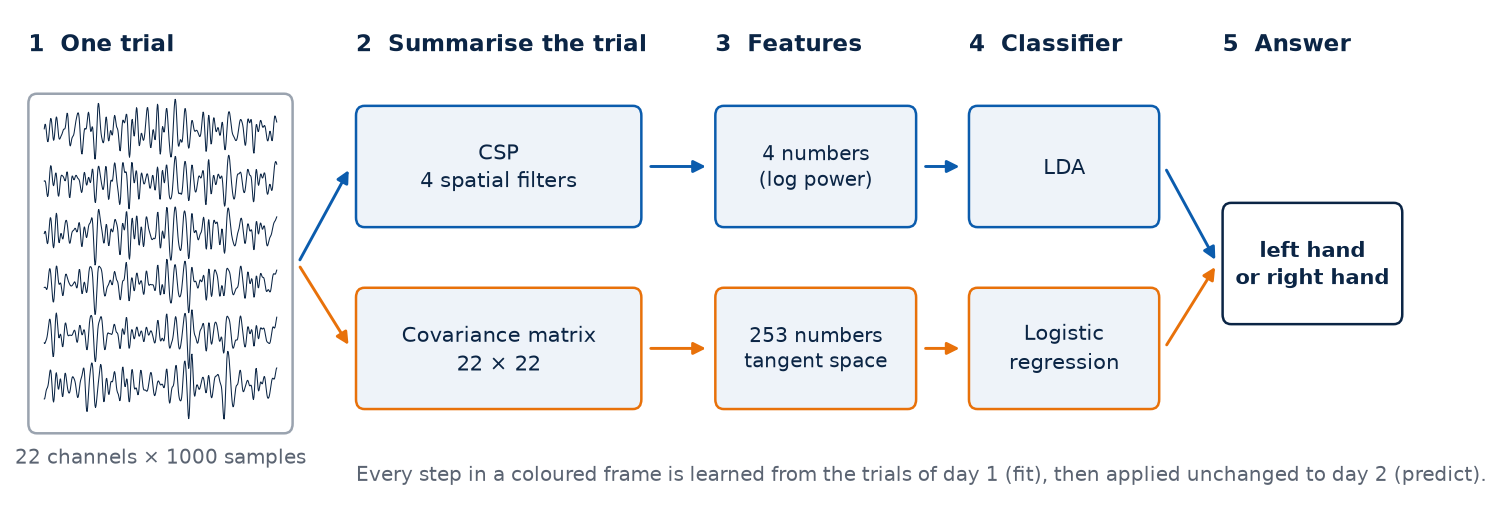

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: features, classifier, training and test</b><br>A trial is 22,000 numbers (22 channels × 1000 samples), far too many to compare directly. We first turn it into a few numbers that carry the information: the <b>features</b>. A <b>classifier</b> is a rule that goes from the features to a <b>label</b>, here <i>left hand</i> or <i>right hand</i>.<br>The rule is not written by hand. It is <b>learned</b> from trials whose label we know: the <b>training set</b> (day 1). We then measure how often it is right on trials it has never seen: the <b>test set</b> (day 2). In scikit-learn, learning is <code>fit</code> and applying is <code>predict</code>.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Load the trials

The same trials as in notebook 1: the 4 s after the cue, 22 channels, filtered from 8 to 30 Hz so that only the mu and beta rhythms remain.

In [3]:
# ---- Trials of every participant, filtered in the mu and beta bands, and the split
X, y, meta = mf.load_epochs(SUBJECTS, fmin=BAND[0], fmax=BAND[1])
X = X.astype(np.float64)                             # the decoders below expect double precision
train = (meta["session"] == "0train").to_numpy()     # day 1
test = (meta["session"] == "1test").to_numpy()       # day 2

person = (meta["subject"] == SUBJECT).to_numpy()     # one participant for parts 1 to 4
X_p, y_p = X[person], y[person]
day1, day2 = train[person], test[person]

print("All participants:", X.shape, "(trials, channels, samples)")
print(f"Participant {SUBJECT}: {day1.sum()} trials to train on (day 1), {day2.sum()} to test on (day 2)")

All participants: (2592, 22, 1000) (trials, channels, samples)
Participant 1: 144 trials to train on (day 1), 144 to test on (day 2)


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Two features made by hand

Notebook 1 ended with four hand-made features and a logistic regression. We start again from an even simpler version, to see what a classifier does: two features, the power at **C3** and the power at **C4**, taken from the signal as recorded, without the local reference of notebook 1. The signal is already filtered from 8 to 30 Hz, so its **variance** over the trial is its power in that band. We take the logarithm, which makes the values easier to separate with a line.

features: (288, 2) (trials, features)


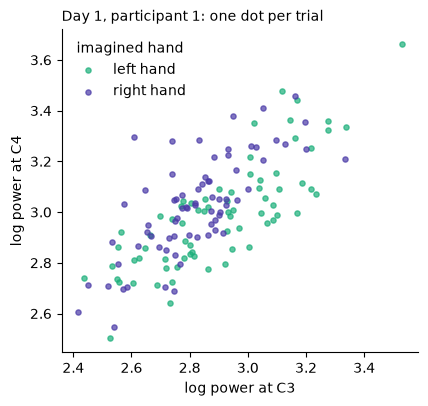

In [4]:
# ---- Two numbers per trial: log power at C3 and at C4
def log_power(X, names):
    """Log of the variance of each trial at the named electrodes (trials x electrodes)."""
    picks = [mf.CHANNELS.index(name) for name in names]
    return np.log(X[:, picks].var(axis=-1))


features = log_power(X_p, ["C3", "C4"])
print("features:", features.shape, "(trials, features)")

fig, ax = plt.subplots(figsize=(4.6, 4.2))
for cls, color in HANDS.items():
    rows = day1 & (y_p == cls)
    ax.scatter(features[rows, 0], features[rows, 1], s=14, color=color, alpha=0.7, label=cls.replace("_", " "))
ax.set_xlabel("log power at C3")
ax.set_ylabel("log power at C4")
ax.set_title(f"Day 1, participant {SUBJECT}: one dot per trial", loc="left", fontsize=10)
ax.legend(title="imagined hand")
plt.show()

Each dot is one trial of day 1. The two colours overlap almost completely: at one electrode, the power varies far more from trial to trial than between the two hands. Look along the diagonal instead. Right-hand trials tend to sit above it (more power at C4 than at C3), left-hand trials below.

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: LDA</b><br><b>Linear discriminant analysis (LDA)</b> is one of the simplest classifiers. It assumes that each class is a cloud of points of the same shape, finds the centre of each cloud, and draws the <b>straight line</b> that separates them best. A new trial gets the label of the side it falls on. With more than two features the line becomes a plane, but the idea is the same.</div>

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> Train a classifier on these two features

Fit the LDA on the trials of day 1, then compute its balanced accuracy on day 2 (the proportion of correct answers; 0.5 is chance).

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>lda.fit(features_of_day_1, labels_of_day_1)</code>, then <code>lda.predict(features_of_day_2)</code>. The day-1 rows are <code>features[day1]</code> and <code>y_p[day1]</code>. <code>balanced_accuracy_score(true_labels, predicted_labels)</code>.</div>

In [5]:
# ---- Exercise: fit an LDA on day 1 and score it on day 2
lda = LinearDiscriminantAnalysis()
...                                                  # <--- fit `lda` on the features and labels of day 1
accuracy_by_hand = ...                               # <--- balanced accuracy of its predictions on day 2

In [6]:
#@title Solution (try first)
# ---- Fit an LDA on day 1 and score it on day 2
lda = LinearDiscriminantAnalysis()
lda.fit(features[day1], y_p[day1])
accuracy_by_hand = balanced_accuracy_score(y_p[day2], lda.predict(features[day2]))
print(f"Balanced accuracy on day 2: {accuracy_by_hand:.2f}")

Balanced accuracy on day 2: 0.62


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> See the rule the classifier learned

The function below draws the trials of each day in the plane of two features, with the line of a fitted classifier. We reuse it in the next parts.

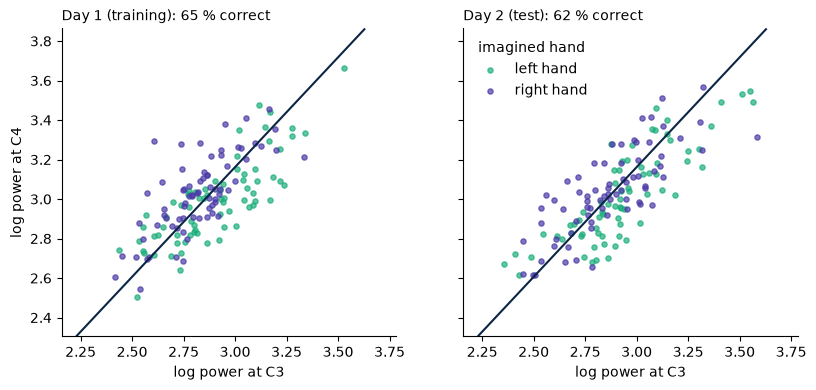

In [7]:
# ---- Draw two features on each day, with the line learned on day 1
def plot_features(features, classifier, labels):
    """Day-1 and day-2 trials in the plane of two features; the line is where the classifier changes its answer."""
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 4), sharex=True, sharey=True)
    low, high = features.min(axis=0) - 0.2, features.max(axis=0) + 0.2
    grid_x, grid_y = np.meshgrid(np.linspace(low[0], high[0], 200), np.linspace(low[1], high[1], 200))
    side = classifier.decision_function(np.column_stack([grid_x.ravel(), grid_y.ravel()])).reshape(grid_x.shape)
    for ax, day, name in zip(axes, [day1, day2], ["Day 1 (training)", "Day 2 (test)"]):
        for cls, color in HANDS.items():
            rows = day & (y_p == cls)
            ax.scatter(features[rows, 0], features[rows, 1], s=14, color=color, alpha=0.7, label=cls.replace("_", " "))
        ax.contour(grid_x, grid_y, side, levels=[0], colors="#0B2545", linewidths=1.5)
        score = balanced_accuracy_score(y_p[day], classifier.predict(features[day]))
        ax.set_title(f"{name}: {100 * score:.0f} % correct", loc="left", fontsize=10)
        ax.set_xlabel(labels[0])
    axes[0].set_ylabel(labels[1])
    axes[1].legend(title="imagined hand")
    plt.show()


plot_features(features, lda, ["log power at C3", "log power at C4"])

The line is close to the diagonal: the classifier learned to compare C4 with C3, as we did by eye in notebook 1. With participant 1 it is right for 62 % of the day-2 trials. That is better than chance (50 %) and far from useful.

## 2. CSP: learning how to combine the electrodes

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>Instead of two electrodes chosen by hand, CSP learns from the labelled trials how to combine all 22 so that the two hands differ as much as possible.</div>

C3 and C4 were our choice. They are probably not the best choice for every person, and each electrode on its own mostly picks up activity shared with its neighbours.

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: CSP</b><br>A <b>spatial filter</b> is a weighted sum of the electrodes: one new signal made from the 22. <b>Common spatial patterns (CSP)</b> learns the weights from the training trials. It looks for the filter whose power is as <b>high as possible for one hand and as low as possible for the other</b>, then for the opposite one, and so on (Ramoser et al., 2000; Blankertz et al., 2008). We keep a few filters, here 4. The features are the log power of each filtered signal: 4 numbers per trial instead of our 2.</div>

<details><summary>The mathematics, in three lines</summary>

Let $C_L$ and $C_R$ be the mean covariance matrices of left- and right-hand training trials. The power of a filter $w$ is $w^\top C_L w$ for the left hand and $w^\top C_R w$ for the right hand. CSP finds the filters that make the ratio $\dfrac{w^\top C_L w}{w^\top C_R w}$ as large or as small as possible. They are the solutions of the generalised eigenvalue problem $C_L w = \lambda C_R w$, which a computer solves at once.
</details>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Learn the filters on day 1

features_csp: (288, 4) (trials, filters)


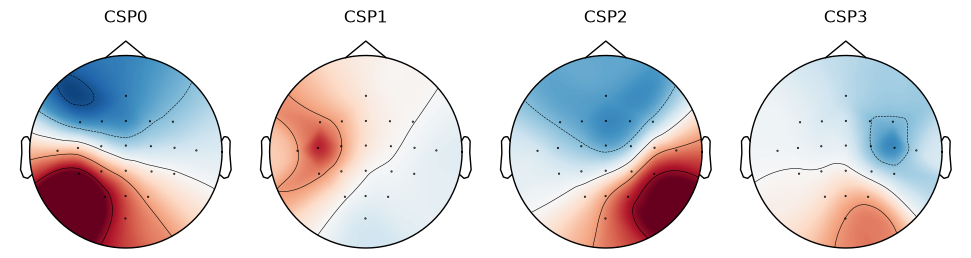

In [8]:
# ---- Fit CSP on day 1, then turn every trial into 4 numbers
csp = CSP(n_components=N_FILTERS, log=True)          # log=True: the features are log powers
csp.fit(X_p[day1], y_p[day1])
features_csp = csp.transform(X_p)
print("features_csp:", features_csp.shape, "(trials, filters)")

info, sphere = mf.head_info()                        # electrode positions and head circle
csp.plot_patterns(info, components=list(range(N_FILTERS)), colorbar=False, size=1.6, sphere=sphere, contours=4);

A filter says how to weight the electrodes. Its **pattern**, drawn above, shows where on the head the activity it picks up comes from: this is the picture to interpret.

With participant 1, each pattern sits on one side of the head, two on the left and two on the right, around and behind C3 and C4. CSP found by itself the left/right difference of notebook 1, without being told where to look. Only the shape matters: the sign of a pattern (red or blue) is arbitrary.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Do the CSP features separate the hands better?

The same picture as in part 1, with the first two CSP features in place of C3 and C4.

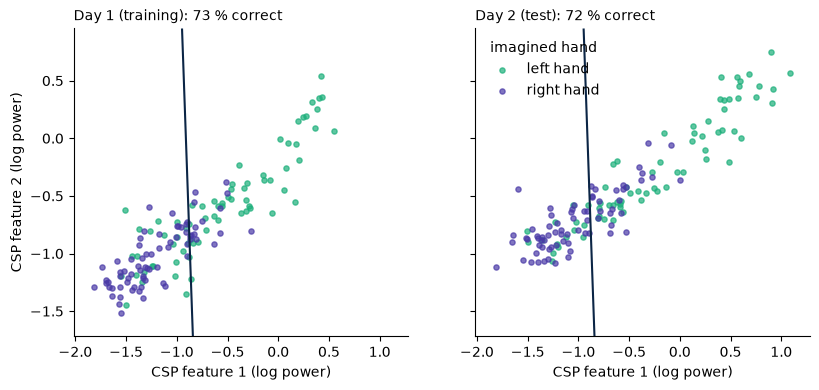

In [9]:
# ---- The first two CSP features on each day, with an LDA fitted on day 1
lda_csp = LinearDiscriminantAnalysis().fit(features_csp[day1, :2], y_p[day1])
plot_features(features_csp[:, :2], lda_csp, ["CSP feature 1 (log power)", "CSP feature 2 (log power)"])

With participant 1 the two clouds come apart: left-hand trials have more power in both filters. Two CSP features give 72 % on day 2, against 62 % for C3 and C4, and the picture is similar on both days.

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> Chain the steps in a pipeline

Until now we called CSP and LDA one after the other. A scikit-learn **pipeline** chains them into one object: `fit` learns every step on the training trials, `predict` applies them in order. It also makes it impossible to fit a step on the test trials by mistake.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>make_pipeline(step_1, step_2)</code>: <a href='https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html'>documentation</a>. The steps are a <code>CSP</code> with <code>N_FILTERS</code> filters and <code>log=True</code>, then an LDA. The pipeline takes the trials themselves: <code>X_p[day1]</code>.</div>

In [10]:
# ---- Exercise: CSP and LDA in one pipeline, fitted on day 1
csp_lda = ...                                        # <--- make_pipeline(CSP(...), LinearDiscriminantAnalysis())
fitted = ...                                         # <--- csp_lda.fit(trials of day 1, labels of day 1)

In [11]:
#@title Solution (try first)
# ---- CSP and LDA in one pipeline, fitted on day 1
csp_lda = make_pipeline(CSP(n_components=N_FILTERS, log=True), LinearDiscriminantAnalysis())
csp_lda.fit(X_p[day1], y_p[day1])

accuracy_csp = balanced_accuracy_score(y_p[day2], csp_lda.predict(X_p[day2]))
print(f"Participant {SUBJECT}, C3 and C4 by hand: {100 * accuracy_by_hand:.0f} % of day-2 trials correct")
print(f"Participant {SUBJECT}, CSP + LDA:         {100 * accuracy_csp:.0f} %")

Participant 1, C3 and C4 by hand: 62 % of day-2 trials correct
Participant 1, CSP + LDA:         83 %


## 3. Reading a score

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>Look at which errors a decoder makes as well as how many, and never score it on the trials it learned from.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: confusion matrix, balanced accuracy, ROC AUC</b><br>The <b>confusion matrix</b> counts the test trials by true label (rows) and predicted label (columns): the diagonal holds the correct answers. <b>Balanced accuracy</b> is the proportion of correct answers computed separately for each class, then averaged, so that a decoder that always answers <i>left</i> gets 50 % and not more.<br>A classifier also gives a <b>confidence</b> for each trial. The <b>ROC curve</b> shows what happens when we move the threshold on that confidence: how many right-hand trials we catch against how many left-hand trials we wrongly call right. The area under it, the <b>ROC AUC</b>, is 0.5 for a decoder that guesses and 1 for a perfect one.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> The answers of CSP + LDA on day 2

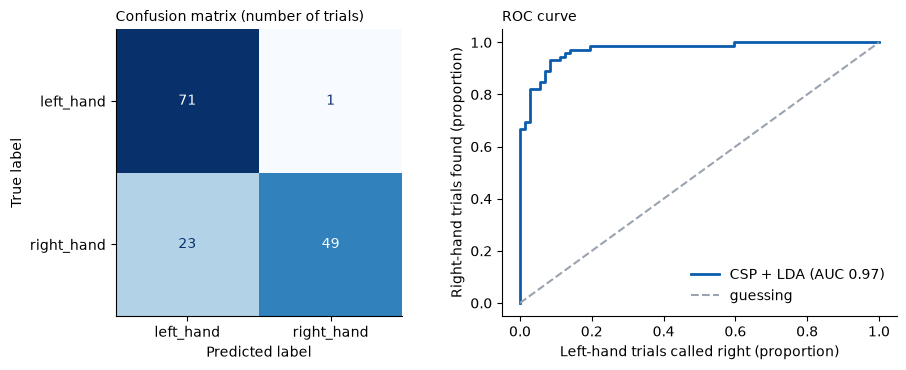

In [12]:
# ---- Confusion matrix and ROC curve of CSP + LDA on day 2
predicted = csp_lda.predict(X_p[day2])
confidence = csp_lda.predict_proba(X_p[day2])[:, list(csp_lda.classes_).index("right_hand")]   # P(right hand)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
ConfusionMatrixDisplay.from_predictions(y_p[day2], predicted, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix (number of trials)", loc="left", fontsize=10)
false_alarms, found, _ = roc_curve(y_p[day2] == "right_hand", confidence)
auc = roc_auc_score(y_p[day2] == "right_hand", confidence)
axes[1].plot(false_alarms, found, color=COLORS["CSP + LDA"], lw=2, label=f"CSP + LDA (AUC {auc:.2f})")
axes[1].plot([0, 1], [0, 1], color="#9AA3AF", ls="--", label="guessing")
axes[1].set_xlabel("Left-hand trials called right (proportion)")
axes[1].set_ylabel("Right-hand trials found (proportion)")
axes[1].set_title("ROC curve", loc="left", fontsize=10)
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

With participant 1, 71 of the 72 left-hand trials are correct, but 23 of the 72 right-hand trials are called left: on day 2 the decoder leans towards "left". The ROC curve does not depend on where the threshold sits, so the AUC (0.97) is much better than the accuracy (83 %). The two hands are well separated, but the line learned on day 1 is no longer in the right place on day 2. This is the change between days of notebook 1, seen in a decoder.

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> Balanced accuracy from the confusion matrix

Compute the balanced accuracy yourself from the four counts.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>counts</code> has one row per true label. The correct answers are on the diagonal: <code>np.diag(counts)</code>. The number of trials of each true label is <code>counts.sum(axis=1)</code>.</div>

In [13]:
# ---- Exercise: balanced accuracy from the confusion matrix
counts = confusion_matrix(y_p[day2], predicted)      # rows: true label, columns: predicted label
correct_per_class = ...                              # <--- proportion of correct answers for each true label
balanced = ...                                       # <--- their mean

In [14]:
#@title Solution (try first)
# ---- Balanced accuracy from the confusion matrix
counts = confusion_matrix(y_p[day2], predicted)      # rows: true label, columns: predicted label
correct_per_class = np.diag(counts) / counts.sum(axis=1)
balanced = correct_per_class.mean()
print(f"By hand: {balanced:.3f} | scikit-learn: {balanced_accuracy_score(y_p[day2], predicted):.3f}")

By hand: 0.833 | scikit-learn: 0.833


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Why we never score on the training trials

In [15]:
# ---- The same decoder scored on the trials it learned from, and on new trials
on_training = balanced_accuracy_score(y_p[day1], csp_lda.predict(X_p[day1]))
on_test = balanced_accuracy_score(y_p[day2], csp_lda.predict(X_p[day2]))
print(f"Participant {SUBJECT}, CSP + LDA: {100 * on_training:.0f} % on day 1 (training), {100 * on_test:.0f} % on day 2 (test)")

Participant 1, CSP + LDA: 90 % on day 1 (training), 83 % on day 2 (test)


<div style="border-left:5px solid #E8710A; background:#FDF1E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#E8710A;">Watch out</b><br>A decoder is always better on the trials it learned from: it has adapted to their details, including their noise. This is <b>overfitting</b>. The score on the training set says little about how the decoder will do on new data, so every score in this tutorial is computed on day 2.</div>

## 4. Covariance matrices and the tangent space

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>The second decoder keeps the whole table of relations between electrodes instead of a few filters, and uses a geometry made for such tables.</div>

CSP keeps a few filters and throws away the rest. The second decoder keeps everything.

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: covariance matrix</b><br>The <b>covariance matrix</b> of a trial is a 22 × 22 table. On the diagonal: the power of each electrode. Elsewhere: how each pair of electrodes varies together. It summarises the 22,000 numbers of a trial in 253 (the table is symmetric), and it holds everything CSP uses.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> What the covariance matrices look like

covariances: (288, 22, 22) (trials, channels, channels)


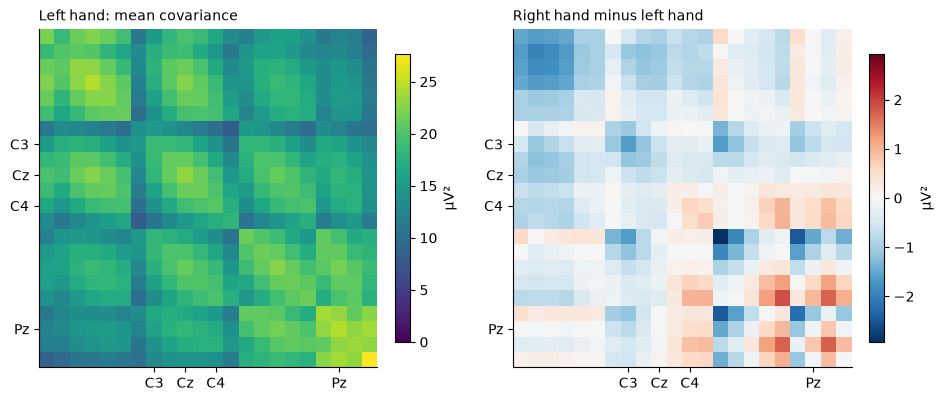

In [16]:
# ---- Mean covariance matrix of each movement on day 1, and their difference
covariances = Covariances(estimator="oas").transform(X_p)            # one 22 x 22 matrix per trial
mean_left = covariances[day1 & (y_p == "left_hand")].mean(axis=0)
mean_right = covariances[day1 & (y_p == "right_hand")].mean(axis=0)
print("covariances:", covariances.shape, "(trials, channels, channels)")

ticks = [mf.CHANNELS.index(name) for name in ["C3", "Cz", "C4", "Pz"]]
difference = mean_right - mean_left
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.9), layout="constrained")
image = axes[0].imshow(mean_left, cmap="viridis", vmin=0)
axes[0].set_title("Left hand: mean covariance", loc="left", fontsize=10)
fig.colorbar(image, ax=axes[0], label="µV²", shrink=0.85)
image = axes[1].imshow(difference, cmap="RdBu_r", vmin=-np.abs(difference).max(), vmax=np.abs(difference).max())
axes[1].set_title("Right hand minus left hand", loc="left", fontsize=10)
fig.colorbar(image, ax=axes[1], label="µV²", shrink=0.85)
for ax in axes:
    ax.set_xticks(ticks, ["C3", "Cz", "C4", "Pz"])
    ax.set_yticks(ticks, ["C3", "Cz", "C4", "Pz"])
plt.show()

With participant 1, the mean matrix has values of 10 to 25 µV² everywhere: the electrodes share much of their signal. The matrix of the right hand looks the same by eye, so the second panel shows the difference. It stays within 3 µV², about a tenth of the values: less power for the right hand at the left-side electrodes behind C3 (blue), more at the right-side electrodes behind C4 (red). The information is there, small and spread over many entries of the table.

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: a curved space, and its flat map</b><br>Covariance matrices are not ordinary tables of numbers: they live on a <b>curved space</b>, a little like points on a globe. On a globe, the straight line between two cities goes through the ground, and the midpoint of that line is not on the surface. In the same way, ordinary averages and straight lines behave badly with covariance matrices. <b>Riemannian geometry</b> gives distances and averages that follow the curve (Barachant et al., 2012).<br>The <b>tangent space</b> is a flat sheet laid on the curved space at the mean matrix, like a flat map of the region around one city. Each trial is moved onto the sheet and becomes an ordinary vector of 253 numbers, on which any ordinary classifier works (Barachant et al., 2013).</div>

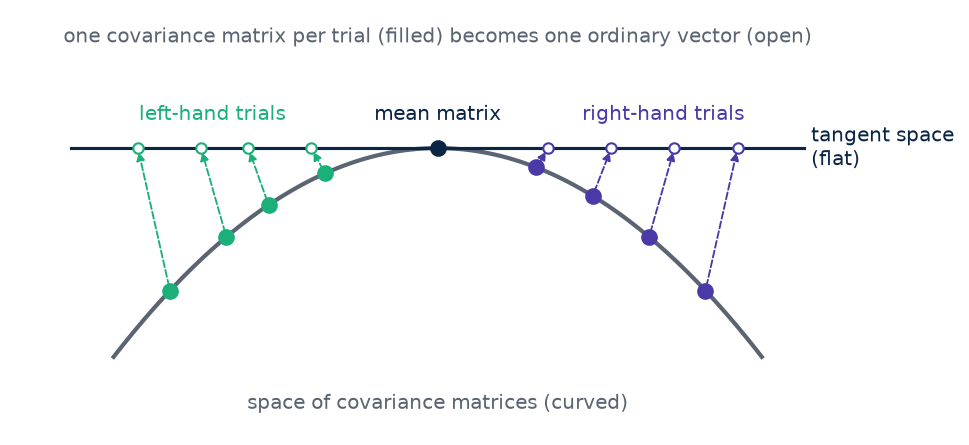

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: logistic regression</b><br><b>Logistic regression (LR)</b> is, like LDA, a classifier that separates the classes with a line or a plane. It learns the plane by making the probability it gives to the correct label as high as possible on the training trials, without assuming anything about the shape of the clouds. It copes well with many features, which is what we have here.</div>

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> Build the second pipeline

Three steps: the covariance matrix of each trial, the move to the tangent space, a logistic regression.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>Covariances(estimator=&quot;oas&quot;)</code> (<a href='https://pyriemann.readthedocs.io/en/latest/generated/pyriemann.estimation.Covariances.html'>documentation</a>; <code>oas</code> is a way of estimating the matrix that stays reliable with few samples), <code>TangentSpace()</code> (<a href='https://pyriemann.readthedocs.io/en/latest/generated/pyriemann.tangentspace.TangentSpace.html'>documentation</a>), <code>LogisticRegression(max_iter=1000)</code>.</div>

In [17]:
# ---- Exercise: covariance, tangent space and logistic regression in one pipeline
tangent_lr = ...                                     # <--- make_pipeline with the three steps
fitted = ...                                         # <--- tangent_lr.fit(trials of day 1, labels of day 1)

In [18]:
#@title Solution (try first)
# ---- Covariance, tangent space and logistic regression in one pipeline
tangent_lr = make_pipeline(Covariances(estimator="oas"), TangentSpace(), LogisticRegression(max_iter=1000))
tangent_lr.fit(X_p[day1], y_p[day1])

accuracy_tangent = balanced_accuracy_score(y_p[day2], tangent_lr.predict(X_p[day2]))
print(f"Participant {SUBJECT}, CSP + LDA:          {100 * accuracy_csp:.0f} % of day-2 trials correct")
print(f"Participant {SUBJECT}, tangent space + LR: {100 * accuracy_tangent:.0f} %")

Participant 1, CSP + LDA:          83 % of day-2 trials correct
Participant 1, tangent space + LR: 88 %


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> A look at the tangent space

253 dimensions cannot be drawn. **Principal component analysis (PCA)** finds the two directions along which the training trials vary most, and we draw the trials in that plane. The line is an LDA fitted on these two numbers only, for the picture: the real decoder uses all 253.

tangent_vectors: (288, 253) (trials, features)


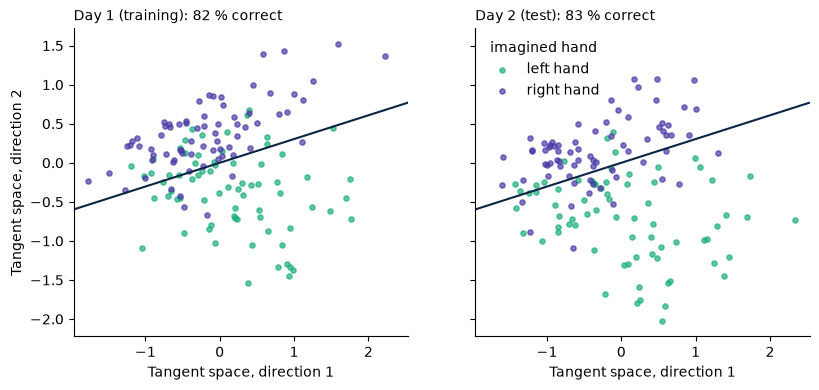

In [19]:
# ---- The trials in the tangent space, seen along its two main directions
tangent_vectors = tangent_lr[:2].transform(X_p)                      # covariance, then tangent space
print("tangent_vectors:", tangent_vectors.shape, "(trials, features)")
pca = PCA(n_components=2).fit(tangent_vectors[day1])
plane = pca.transform(tangent_vectors)
plot_features(plane, LinearDiscriminantAnalysis().fit(plane[day1], y_p[day1]),
              ["Tangent space, direction 1", "Tangent space, direction 2"])

With participant 1, the two hands already come apart along the second direction, on both days, with 2 numbers out of 253.

## 5. All participants

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>Both decoders work for some people and fail for others. The difference between people is far larger than the difference between methods.</div>

<div style="border-left:5px solid #B45309; background:#FEF6E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#B45309;">Question</b><br>Before running the next cell: from notebook 1, which participants do you expect to be hard to decode?</div>

One participant is not the dataset. We now do the same for everyone.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> One function for every participant and pipeline

`evaluate` builds a new pipeline, fits it on day 1 of one participant, and returns its balanced accuracy and ROC AUC on day 2, with the time it took.

In [20]:
# ---- Train on day 1 and test on day 2, for every participant and both pipelines
PIPELINES = {
    "CSP + LDA": lambda: make_pipeline(CSP(n_components=N_FILTERS, log=True), LinearDiscriminantAnalysis()),
    "Tangent space + LR": lambda: make_pipeline(Covariances(estimator="oas"), TangentSpace(),
                                                LogisticRegression(max_iter=1000)),
}


def evaluate(make_pipeline_, subject, X=X):
    """Fit a new pipeline on day 1 of one participant; return its scores on day 2 and the time taken."""
    person = (meta["subject"] == subject).to_numpy()
    start = time.time()
    model = make_pipeline_().fit(X[person & train], y[person & train])
    confidence = model.predict_proba(X[person & test])[:, list(model.classes_).index("right_hand")]
    return {"balanced_accuracy": balanced_accuracy_score(y[person & test], model.predict(X[person & test])),
            "auc": roc_auc_score(y[person & test] == "right_hand", confidence),
            "seconds": time.time() - start}


scores = pd.DataFrame([{"method": name, "subject": subject, **evaluate(make, subject)}
                       for name, make in PIPELINES.items() for subject in SUBJECTS])
table = scores.pivot(index="method", columns="subject", values="balanced_accuracy").loc[list(PIPELINES)]
table["mean"] = table.mean(axis=1)
(100 * table).round(0)

subject,1,2,3,4,5,6,7,8,9,mean
method,,,,,,,,,,
CSP + LDA,83.0,49.0,90.0,71.0,58.0,72.0,51.0,94.0,89.0,73.0
Tangent space + LR,88.0,59.0,96.0,75.0,59.0,73.0,56.0,97.0,85.0,76.0


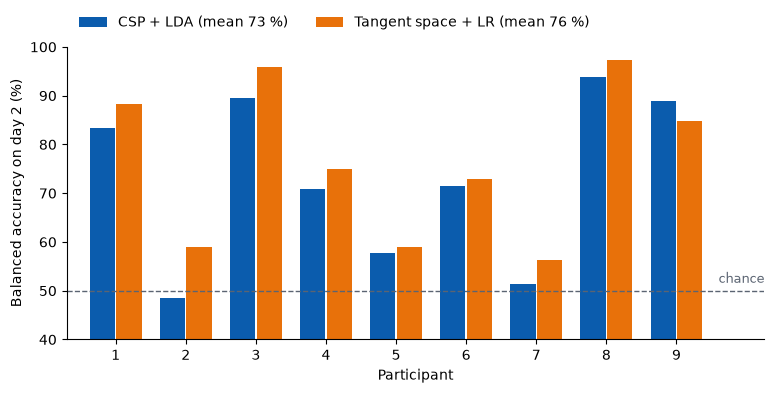

In [21]:
# ---- Balanced accuracy on day 2, per participant
fig, ax = plt.subplots(figsize=(9, 3.8))
for k, (name, color) in enumerate(COLORS.items()):
    values = 100 * table.loc[name, SUBJECTS]
    ax.bar(np.arange(len(SUBJECTS)) + 0.38 * (k - 0.5), values, width=0.36, color=color,
           label=f"{name} (mean {100 * table.loc[name, 'mean']:.0f} %)")
ax.axhline(50, color="#5B6472", lw=1, ls="--")
ax.text(len(SUBJECTS) - 0.4, 51, "chance", color="#5B6472", fontsize=9, va="bottom")
ax.set_xlim(-0.7, len(SUBJECTS) + 0.25)
ax.set_xticks(range(len(SUBJECTS)), SUBJECTS)
ax.set_xlabel("Participant")
ax.set_ylabel("Balanced accuracy on day 2 (%)")
ax.set_ylim(40, 100)
ax.legend(loc="upper left", ncols=2, bbox_to_anchor=(0, 1.15))
plt.show()

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br>With the 9 participants, tangent space + LR is a little ahead: 76 % against 73 % on average, and higher in 8 of 9 people, as in the MOABB benchmark (Jayaram and Barachant, 2018). The differences between people are much larger than between methods, from chance to above 90 %. The participants near chance are those of notebook 1 with no difference between sides: 2 and 5 showed no drop of power, and 7 a large drop that was the same on both sides.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Save the scores

One row per method and participant, in `results/classical.csv`. Notebook 5 reads this file to build the final table.

In [22]:
# ---- Save the scores for notebook 5
scores = scores.assign(training_data="own day 1", training_labels="100 %", adapted_parameters="none", hardware="CPU")
scores.to_csv(RESULTS_DIR / "classical.csv", index=False)
print("Saved", len(scores), "rows to", RESULTS_DIR / "classical.csv")
scores.groupby("method", sort=False)[["balanced_accuracy", "auc", "seconds"]].mean().round(2)

Saved 18 rows to results/classical.csv


,balanced_accuracy,auc,seconds
method,,,
CSP + LDA,0.73,0.82,0.14
Tangent space + LR,0.76,0.87,0.25


## 6. What a random split would have shown

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>The same decoder scores higher when its test trials come from the same day as its training trials.</div>

<div style="border-left:5px solid #B45309; background:#FEF6E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#B45309;">Question</b><br>A paper reports 90 % on this dataset. What do you need to know before comparing that number with our table?</div>

<div style="border-left:5px solid #E8710A; background:#FDF1E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#E8710A;">Watch out</b><br>Many papers report motor-imagery scores from a <b>random split</b>: the trials of both days are mixed, and a random half is used for training. The decoder then trains on trials recorded minutes away from the test trials, in the same session. This is the <b>data leakage</b> of notebook 1.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Day split against random split

Same pipelines, same number of training trials (144), but drawn at random from both days. Five random draws per participant.

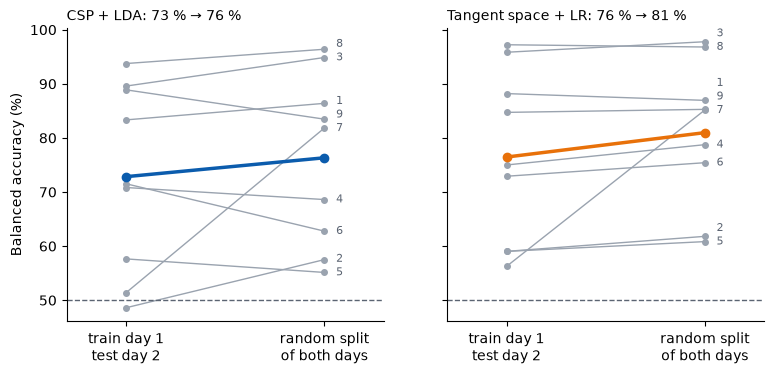

In [23]:
# ---- The same pipelines with a random half of both days as training set
def evaluate_random(make_pipeline_, subject, n_draws=5):
    """Mean balanced accuracy over random 50/50 splits of the trials of both days."""
    person = (meta["subject"] == subject).to_numpy()
    X_p, y_p = X[person], y[person]
    draws = StratifiedShuffleSplit(n_splits=n_draws, train_size=0.5, random_state=0).split(X_p, y_p)
    return np.mean([balanced_accuracy_score(y_p[te], make_pipeline_().fit(X_p[tr], y_p[tr]).predict(X_p[te]))
                    for tr, te in draws])


random_split = pd.DataFrame({name: [evaluate_random(make, subject) for subject in SUBJECTS]
                             for name, make in PIPELINES.items()}, index=SUBJECTS).T
random_split["mean"] = random_split.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, (name, color) in zip(axes, COLORS.items()):
    day, rnd = 100 * table.loc[name, SUBJECTS], 100 * random_split.loc[name, SUBJECTS]
    ax.plot([0, 1], [day, rnd], color="#9AA3AF", lw=1, marker="o", ms=4)
    label_y = -np.inf                                            # participant numbers, moved apart when they overlap
    for subject, value in rnd.sort_values().items():
        label_y = max(value, label_y + 2.5)
        ax.text(1.06, label_y, str(subject), va="center", fontsize=8, color="#5B6472")
    ax.plot([0, 1], [day.mean(), rnd.mean()], color=color, lw=2.5, marker="o")
    ax.axhline(50, color="#5B6472", lw=1, ls="--")
    ax.set_xticks([0, 1], ["train day 1\ntest day 2", "random split\nof both days"])
    ax.set_xlim(-0.3, 1.3)
    ax.set_title(f"{name}: {day.mean():.0f} % → {rnd.mean():.0f} %", loc="left", fontsize=10)
axes[0].set_ylabel("Balanced accuracy (%)")
plt.show()

With the 9 participants, the random split gives 3 to 5 points more on average, with the same decoders and the same number of training trials. The gain is not the same for everyone: participant 7 goes from chance to above 80 %. Their decoder works within a day and fails across days, which a random split hides. When you read a motor-imagery score, check which split produced it.

## 7. Go further (optional)

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> A third decoder

**Minimum distance to mean (MDM)** keeps the mean covariance matrix of each movement and gives a trial the label of the closest one, with a distance that follows the curved space (Barachant et al., 2012). No classifier is trained. Complete the pipeline and compare with the two others.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>MDM()</code> goes after <code>Covariances(estimator=&quot;oas&quot;)</code> in a pipeline, in place of the tangent space and the logistic regression (<a href='https://pyriemann.readthedocs.io/en/latest/generated/pyriemann.classification.MDM.html'>documentation</a>). <code>evaluate</code> needs a function that builds the pipeline, hence the <code>lambda:</code>.</div>

In [24]:
# ---- Exercise: minimum distance to mean on every participant
from pyriemann.classification import MDM

make_mdm = ...                                       # <--- lambda: make_pipeline(Covariances(estimator="oas"), MDM())

if make_mdm is not ...:                              # runs once the line above is completed
    mdm_scores = [evaluate(make_mdm, subject)["balanced_accuracy"] for subject in SUBJECTS]
    print(f"MDM: {100 * np.mean(mdm_scores):.0f} % on average")

In [25]:
#@title Solution (try first)
# ---- Minimum distance to mean on every participant
from pyriemann.classification import MDM

make_mdm = lambda: make_pipeline(Covariances(estimator="oas"), MDM())
mdm = pd.DataFrame([evaluate(make_mdm, subject) for subject in SUBJECTS], index=SUBJECTS)
comparison = table.copy()
comparison.loc["MDM"] = list(mdm["balanced_accuracy"]) + [mdm["balanced_accuracy"].mean()]
(100 * comparison).round(0)
# With the 9 participants MDM reaches 73 % on average, like CSP + LDA and 3 points below tangent space + LR.
# It only stores two mean matrices: no classifier is trained.

subject,1,2,3,4,5,6,7,8,9,mean
method,,,,,,,,,,
CSP + LDA,83.0,49.0,90.0,71.0,58.0,72.0,51.0,94.0,89.0,73.0
Tangent space + LR,88.0,59.0,96.0,75.0,59.0,73.0,56.0,97.0,85.0,76.0
MDM,85.0,55.0,88.0,73.0,51.0,69.0,53.0,98.0,90.0,73.0


### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> Does the band matter?

We filtered from 8 to 30 Hz. Run CSP + LDA on the mu band only (8 to 13 Hz), then on the beta band only (13 to 30 Hz). Which band carries more? About 20 s per band.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br>Give the two limits of the band in Hz: <code>low, high = 8, 13</code>. The rest of the cell loads the trials filtered in that band and evaluates the pipeline on every participant.</div>

In [26]:
# ---- Exercise: CSP + LDA on another band
low, high = ..., ...                                 # <--- the limits of a band in Hz: 8, 13 for mu or 13, 30 for beta

if low is not ...:                                   # runs once the line above is completed
    X_band = mf.load_epochs(SUBJECTS, fmin=low, fmax=high)[0].astype(np.float64)
    band_scores = [evaluate(PIPELINES["CSP + LDA"], subject, X=X_band)["balanced_accuracy"] for subject in SUBJECTS]
    print(f"CSP + LDA, {low}-{high} Hz: {100 * np.mean(band_scores):.0f} % on average "
          f"({BAND[0]}-{BAND[1]} Hz: {100 * table.loc['CSP + LDA', 'mean']:.0f} %)")

In [27]:
#@title Solution (try first)
# ---- CSP + LDA on the mu band and on the beta band
by_band = {f"{BAND[0]}-{BAND[1]} Hz": table.loc["CSP + LDA", SUBJECTS]}
for name, (low, high) in {"mu (8-13 Hz)": (8, 13), "beta (13-30 Hz)": (13, 30)}.items():
    X_band = mf.load_epochs(SUBJECTS, fmin=low, fmax=high)[0].astype(np.float64)
    by_band[name] = pd.Series([evaluate(PIPELINES["CSP + LDA"], subject, X=X_band)["balanced_accuracy"]
                               for subject in SUBJECTS], index=SUBJECTS)
by_band = pd.DataFrame(by_band).T
by_band["mean"] = by_band.mean(axis=1)
(100 * by_band).round(0)
# With the 9 participants the full 8-30 Hz band is best on average (73 %, against 69 % and 70 %).
# People differ: participant 3 is decoded from mu (94 % against 74 % with beta), participant 1 from beta (89 % against 74 %).

,1,2,3,4,5,6,7,8,9,mean
8-30 Hz,83.0,49.0,90.0,71.0,58.0,72.0,51.0,94.0,89.0,73.0
mu (8-13 Hz),74.0,51.0,94.0,56.0,51.0,61.0,55.0,90.0,89.0,69.0
beta (13-30 Hz),89.0,50.0,74.0,69.0,55.0,67.0,60.0,86.0,79.0,70.0


### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> How many training trials are needed?

We trained on the 144 trials of day 1. Train both pipelines on 10 %, 25 % and 50 % of them, drawn at random, and plot the mean balanced accuracy on day 2 against the number of training trials. Notebook 3 asks the same question of REVE.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>StratifiedShuffleSplit(n_splits=3, train_size=fraction, random_state=0).split(X_train, y_train)</code> gives random subsets with as many left- as right-hand trials (<a href='https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html'>documentation</a>). Fit on the subset of day 1, score on all of day 2, average over draws and participants.</div>

In [28]:
# ---- Type 3: balanced accuracy on day 2 against the number of training trials (optional)

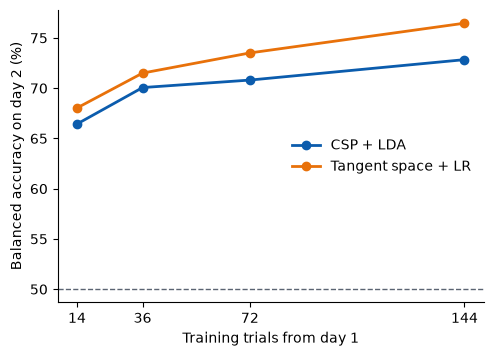

,14,36,72,144
CSP + LDA,66.0,70.0,71.0,73.0
Tangent space + LR,68.0,72.0,74.0,76.0


In [29]:
#@title Solution (try first)
# ---- Balanced accuracy on day 2 against the number of training trials
def score_with_fewer_trials(make_pipeline_, subject, fraction, n_draws=3):
    """Mean day-2 balanced accuracy when only a random fraction of day 1 is used for training."""
    person = (meta["subject"] == subject).to_numpy()
    X_train, y_train = X[person & train], y[person & train]
    draws = StratifiedShuffleSplit(n_splits=n_draws, train_size=fraction, random_state=0).split(X_train, y_train)
    return np.mean([balanced_accuracy_score(y[person & test],
                                            make_pipeline_().fit(X_train[keep], y_train[keep]).predict(X[person & test]))
                    for keep, _ in draws])


fractions = [0.1, 0.25, 0.5]
curve = pd.DataFrame({name: [np.mean([score_with_fewer_trials(make, s, f) for s in SUBJECTS]) for f in fractions]
                      + [table.loc[name, "mean"]] for name, make in PIPELINES.items()},
                     index=[round(144 * f) for f in fractions] + [144])

fig, ax = plt.subplots(figsize=(5.5, 3.8))
for name, color in COLORS.items():
    ax.plot(curve.index, 100 * curve[name], color=color, marker="o", lw=2, label=name)
ax.axhline(50, color="#5B6472", lw=1, ls="--")
ax.set_xticks(curve.index, curve.index)
ax.set_xlabel("Training trials from day 1")
ax.set_ylabel("Balanced accuracy on day 2 (%)")
ax.legend()
plt.show()
(100 * curve).round(0).T
# With the 9 participants, both decoders lose 7 to 8 points when trained on 14 trials instead of 144
# (66 % and 68 %, against 73 % and 76 %). Half of day 1 already gives 71 % and 74 %.

## 8. Summary

| Step | Function | Package |
|---|---|---|
| Trials and split | `mf.load_epochs`, `meta["session"]` | MOABB, pandas |
| Features by hand | log of the variance at C3 and C4 | NumPy |
| Spatial filters | `mne.decoding.CSP`, `plot_patterns` | MNE |
| Covariance, tangent space | `Covariances`, `TangentSpace` | pyRiemann |
| Classifiers | `LinearDiscriminantAnalysis`, `LogisticRegression` | scikit-learn |
| Chain the steps | `make_pipeline`, `fit`, `predict` | scikit-learn |
| Scores | `balanced_accuracy_score`, `roc_auc_score`, `confusion_matrix` | scikit-learn |
| A plane to look at | `PCA` | scikit-learn |

<div style="border-left:5px solid #15803D; background:#ECF8EF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#15803D;">Take-aways</b><br><ul style='margin:0;'><li>A decoder turns a trial into features, and a classifier turns features into a label. Both are learned on day 1 and scored on day 2.</li><li>With the 9 participants, CSP + LDA reaches 73 % and tangent space + LR 76 % balanced accuracy on day 2. Each takes less than a second per participant on a CPU.</li><li>Scores go from chance to above 90 % depending on the person. The people near chance show no difference between sides in notebook 1.</li><li>A random split of both days gives higher scores with the same decoders. We keep day 1 for training and day 2 for testing.</li><li>These scores, saved in <code>results/classical.csv</code>, are what REVE is compared with in notebook 3.</li></ul></div>

**Next**: `03_fm_frozen.ipynb`.

<details><summary>References</summary>

- Barachant, A., Bonnet, S., Congedo, M., & Jutten, C. (2012). Multiclass brain-computer interface classification by Riemannian geometry. *IEEE Transactions on Biomedical Engineering, 59*(4), 920-928. https://doi.org/10.1109/TBME.2011.2172210
- Barachant, A., Bonnet, S., Congedo, M., & Jutten, C. (2013). Classification of covariance matrices using a Riemannian-based kernel for BCI applications. *Neurocomputing, 112*, 172-178. https://doi.org/10.1016/j.neucom.2012.12.039
- Blankertz, B., Tomioka, R., Lemm, S., Kawanabe, M., & Müller, K.-R. (2008). Optimizing spatial filters for robust EEG single-trial analysis. *IEEE Signal Processing Magazine, 25*(1), 41-56. https://doi.org/10.1109/MSP.2008.4408441
- Jayaram, V., & Barachant, A. (2018). MOABB: Trustworthy algorithm benchmarking for BCIs. *Journal of Neural Engineering, 15*(6), 066011. https://doi.org/10.1088/1741-2552/aadea0
- Lotte, F., Bougrain, L., Cichocki, A., Clerc, M., Congedo, M., Rakotomamonjy, A., & Yger, F. (2018). A review of classification algorithms for EEG-based brain-computer interfaces: A 10 year update. *Journal of Neural Engineering, 15*(3), 031005. https://doi.org/10.1088/1741-2552/aab2f2
- Ramoser, H., Müller-Gerking, J., & Pfurtscheller, G. (2000). Optimal spatial filtering of single trial EEG during imagined hand movement. *IEEE Transactions on Rehabilitation Engineering, 8*(4), 441-446. https://doi.org/10.1109/86.895946
</details>